In [2]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

In [3]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "kinase.csv"

In [5]:
# Load data
df = pd.read_csv(DATA, index_col=0)
df = df.reset_index(drop=True)

In [6]:
# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (179827, 5)
<class 'pandas.DataFrame'>
RangeIndex: 179827 entries, 0 to 179826
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   molecule_chembl_id  179827 non-null  str    
 1   standard_value      179827 non-null  float64
 2   standard_units      179827 non-null  str    
 3   target_chembl_id    179827 non-null  str    
 4   smiles              179827 non-null  str    
dtypes: float64(1), str(4)
memory usage: 6.9 MB


In [7]:
# Look at head
df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,standard_value,standard_units,target_chembl_id,smiles
0,CHEMBL13462,4000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
1,CHEMBL13462,16000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
2,CHEMBL13462,800.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
3,CHEMBL13462,9000.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
4,CHEMBL13462,1700.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...


In [35]:
# Keep necessary columns in needed format and save as csv
chembl_df = df[["smiles", "standard_value"]].dropna()
chembl_df = chembl_df[chembl_df["standard_value"] > 0].reset_index(drop=True)
smiles = []
pIC50 = []
for row in chembl_df.itertuples():
    smiles.append(row.smiles)
    pIC50.append(np.log10(row.standard_value))
chembl_df = pd.DataFrame({"smiles": smiles, "pIC50": pIC50})
chembl_df.to_csv(HERE / "chembl_kinase.csv", index=False)
print(f"Rows after cleaning: {len(chembl_df)}, NaN pIC50: {chembl_df['pIC50'].isna().sum()}")
chembl_df.head()
# NBVAL_CHECK_OUTPUT

Rows after cleaning: 179154, NaN pIC50: 0


,smiles,pIC50
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,3.602060
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4.204120
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,2.903090
3,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,3.954243
4,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,3.230449


In [36]:
# Proposal 3: sample a subset for faster prototyping (comment out to use full dataset)
chembl_df = chembl_df.sample(n=10000, random_state=42).reset_index(drop=True)

In [37]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [38]:
chembl_df["fingerprints_df"] = chembl_df["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (10000, 3)


,smiles,pIC50,fingerprints_df
0,Cc1cc(Nc2ncc(Cl)c(Nc3ccccc3S(=O)(=O)C(C)C)n2)c...,4.100371,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(O)(C(=O)Nc1cccc(C(=O)O)c1Cl)C(F)(F)F,4.397940,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CSc1nc(-c2ccc(F)cc2)c(-c2ccnc(NC(C)c3ccccc3)c2...,2.579784,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [39]:
#save the dataframe with fingerprints as csv
chembl_df.to_csv(HERE / "chembl_kinase_fps.csv", index=False)

In [40]:
# Split the data into training and test set x=features, y= target data
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)
# NBVAL_CHECK_OUTPUT

Shape of training data: (7000,)
Shape of test data: (3000,)


Define neural network¶

A keras model is defined by specifying the number of neurons in the hidden layers and the activation function as arguments. For our purpose, we define a model with two hidden layers. We use ReLU in the hidden layers and a linear function on the output layer, since the aim is to predict pIC50 values. Finally, we compile the model using the mean squared error as a loss argument and adam as an optimizer.

In [41]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

Train the model¶

We try different mini-batch sizes and plot the respective losses.

In [42]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 20  # proposal 2: reduced from 50 for faster prototyping
layer1_size = 64
layer2_size = 32

Batch 16: first loss = 1.7733
Batch 32: first loss = 1.8730
Batch 64: first loss = 1.9848


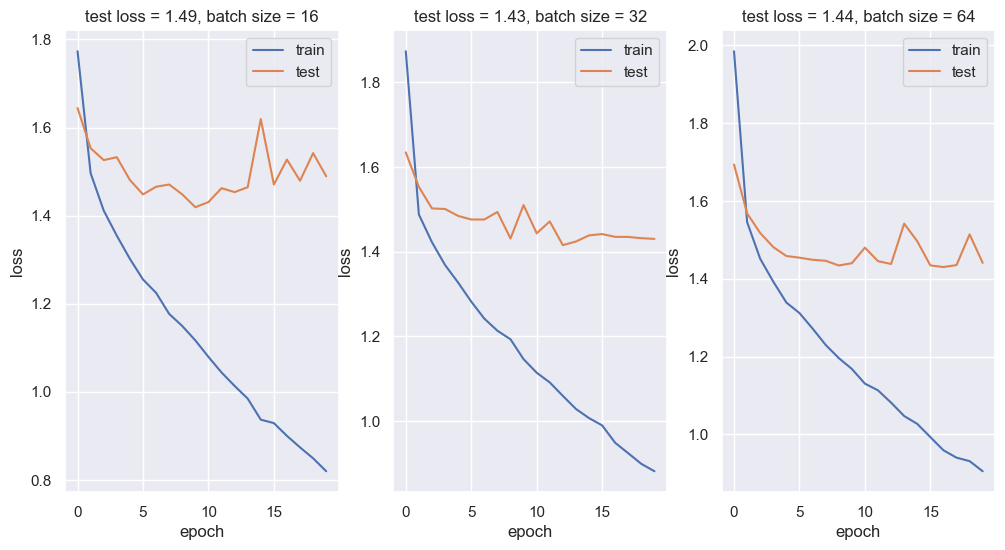

In [43]:
# Pre-convert training and test arrays once (proposal 1: avoid redundant conversion in loop)
X_train = np.array(list(x_train)).astype(float)
X_test = np.array(list(x_test)).astype(float)

# Plot
fig = plt.figure(figsize=(12, 6))
sns.set_theme(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        X_train,
        y_train.values,
        batch_size=batch,
        validation_data=(X_test, y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    first_loss = history.history["loss"][0]
    print(f"Batch {batch}: first loss = {first_loss:.4f}")  # NaN here means bad input data
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()